# Does FRAMA's "fractal-adaptive" smoothing actually buy edge? 〰️
### A clever moving average — fast in trends, slow in chop — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Adaptive_edge%3F: Busted](https://img.shields.io/badge/Adaptive_edge%3F-Busted-8b949e?style=flat-square)

Most moving averages have one speed. **FRAMA** — John Ehlers' *Fractal Adaptive Moving Average* — is supposed to be smarter: it measures the **fractal dimension** of recent price and changes its own smoothing on the fly. In a clean trend it *speeds up* and hugs price; in choppy, sideways action it *slows down* and flattens out. The pitch, repeated on every charting forum, is that this lets a "buy when price crosses above FRAMA" rule **catch trends sooner and dodge the whipsaws** that fool a plain moving average.

It *sounds* clever. But "adaptive" is exactly the kind of word that sells a tool while hiding whether it does anything. So we did the only fair thing: encode FRAMA **exactly as Ehlers specifies**, fire the cross-up rule thousands of times across five big indices over 21 years, and time the result with a stopwatch — against two honest baselines: **buying on random days**, and the same rule on a **plain, fixed-speed moving average**.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from frama import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real FRAMA cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2832, 'n_ema': 2614, 'frama_n': 16, 'fp_spy': '4cb5244f3990', 'h5': (5, 2830, 18.9, 58, 3.48, 29.7, -10.8, 18.9, 0.0, 16.9, -1.51, 0.131), 'h10': (10, 2828, 51.2, 61, 6.1, 50.8, 0.4, 46.2, 5.0, 49.2, 0.04, 0.97), 'h20': (20, 2823, 102.1, 64, 7.27, 99.3, 2.8, 88.6, 13.4, 100.1, 0.2, 0.841), 'h60': (60, 2805, 285.0, 69, 8.08, 257.9, 27.1, 278.6, 6.3, 283.0, 1.17, 0.244), 'per': [('SPY', 559, 85.9, 3.63, 104.5, -18.6, 3.2), ('QQQ', 581, 112.4, 3.08, 123.9, -11.6, 5.0), ('IWM', 560, 84.7, 2.46, 86.0, -1.3, -16.0), ('DIA', 569, 88.2, 3.39, 89.8, -1.6, 30.9), ('GLD', 563, 138.7, 4.47, 91.3, 47.4, 44.3)], 'placebo': (85.9, 0.417, 500), 'syn': [(0.0, 550, 3.2, 46, 0.12), (2.0, 100, 2136.1, 67, 4.11)]}


real FRAMA cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when price crosses above FRAMA, do I make money? | **Yes — but only because the market goes up.** The win-rate is ~60% and the returns look great. |
| Is that *FRAMA's* doing? | **No.** Buy on **random days** instead and you do just as well — the cross-up adds essentially nothing. |
| Is the "fractal-adaptive" part worth anything? | **No.** Run the *exact same rule* on a **plain fixed-speed moving average** and you land in the same place. |
| Does the fractal dimension carry information? | **No.** Scramble the adaptation in time and the result barely changes. The fractal machinery is decorative. |

> FRAMA is a perfectly fine way to *draw* a trend. As a *forecast* — "the cross-up will pay" — it's a **mirage**: all of the apparent edge is the market's long-run climb, none of it is the fractal adaptation.

## 1 · The claim

> *"A normal moving average lags. FRAMA measures the **fractal dimension** of the last few bars — how 'rough' or 'straight' the path is — and adapts its smoothing: near 1 (a straight trend) it follows fast; near 2 (jagged chop) it slows to a crawl. So it tracks trends tightly and ignores noise. Buy when price crosses above it."*

This is **John Ehlers'** FRAMA (*Stocks & Commodities*, 2005), built into most charting suites and a staple of the "adaptive indicator" genre. The smoothing constant is literally `alpha = exp(−4.6·(D−1))`, where `D` is the fractal dimension. So: does the clever adaptation actually *forecast* — or is it a fancier way to lag?

## 2 · So what?

If FRAMA genuinely *forecast* trends better than a dumb moving average, that would be a real, tradable edge — a crack in market efficiency you could mechanize. That's the dream the "adaptive" label sells.

But there are two traps. First, FRAMA is a **moving average of past price** drawn on a market (stock indices) that drifts **up** over time — so *any* "buy above the average" rule will look profitable, fractal or not. Second, "adaptive" might just be a more complicated way to compute the same lagging line. To separate the **tool** from the **tide** we (a) race FRAMA against buying on **random days**, and (b) race it against the same rule on a **plain fixed-speed EMA**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Compute FRAMA mechanically.** Ehlers' recursion over an **N = 16-bar** window — strictly causal, no peeking at future bars.
2. **Trade the lore.** Buy the bar the close first **crosses above FRAMA**, at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baselines.** Do the exact same hold on **random days** (the drift baseline), and run the same cross-up on a **plain fixed-speed EMA** (the 'is adaptation worth it?' baseline). If FRAMA matters, it must beat both.
4. *If it doesn't, the tool is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does FRAMA even look like, and how does it differ from a fixed moving average? Here's SPY with FRAMA (adaptive) and a plain EMA of the same average speed, plus the cross-up buys the rule would fire.

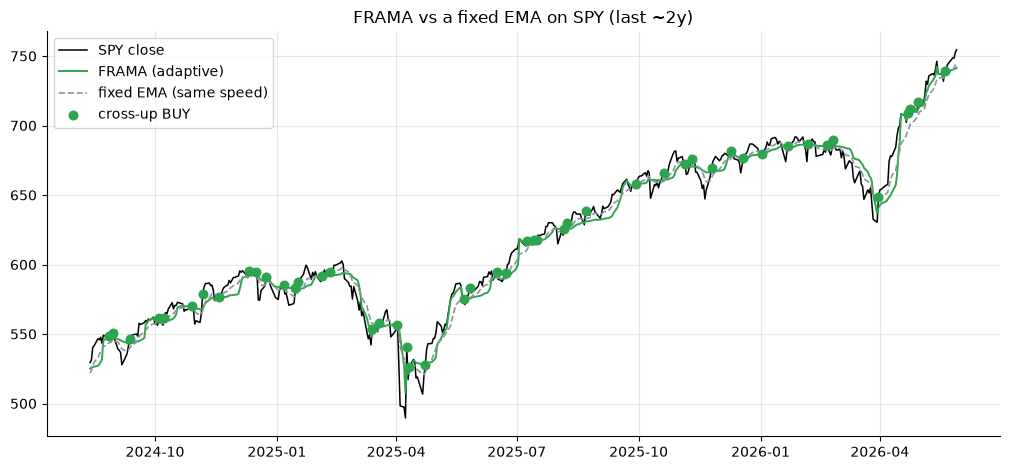

FRAMA cross-ups in window: 49


In [2]:
if HAVE_REAL:
    b = load('SPY'); cl = b['close']; seg = cl.iloc[-450:]
    fr = st.frama(b, n=R['frama_n']); em = st.fixed_ema(b, n=R['frama_n'])
    ent = st.frama_cross_entries(b, n=R['frama_n']); ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.1, label='SPY close')
    ax.plot(seg.index, fr.reindex(seg.index), c=GREEN, lw=1.4, label='FRAMA (adaptive)')
    ax.plot(seg.index, em.reindex(seg.index), c=GREY, lw=1.2, ls='--', label='fixed EMA (same speed)')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=38, zorder=5, label='cross-up BUY')
    ax.set_title('FRAMA vs a fixed EMA on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('FRAMA cross-ups in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

FRAMA and the fixed EMA track each other closely — the "adaptive" line is rarely far from a plain one. The question is whether those green buy dots are followed by real trends. **Let's race the FRAMA cross-up against random entries** at four horizons. Blue = buy the FRAMA cross-up; grey = buy on random days.

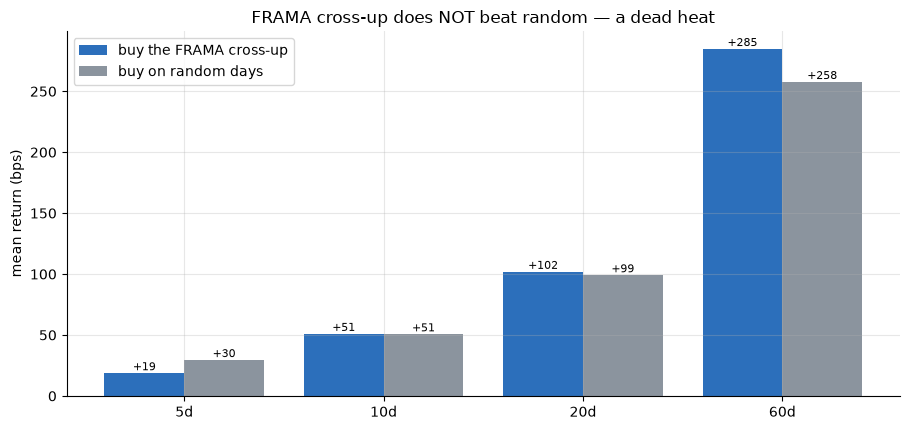

FRAMA: [19, 51, 102, 285]
random: [30, 51, 99, 258]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    frama_b, rnd = [], []
    for h in hs:
        ff, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); c = b['close']
            e = st.frama_cross_entries(b, n=R['frama_n'])
            re = st.random_entries(c, max(len(e),50), n=R['frama_n'], seed=7)
            ff.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        frama_b.append(np.concatenate(ff).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    frama_b = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, frama_b, .4, color='#2c6fbb', label='buy the FRAMA cross-up')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(frama_b,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('FRAMA cross-up does NOT beat random — a dead heat'); ax.legend()
plt.tight_layout(); plt.show()
print('FRAMA:', [round(v) for v in frama_b]); print('random:', [round(v) for v in rnd])

There's the story in one chart. The FRAMA cross-up makes money in absolute terms (**+102 bps** over 20 days) — but so does **buying on random days** (**+99 bps**). It's a dead heat at every horizon; at 5 days FRAMA is actually *behind* a coin flip. The apparent edge was **the market's upward drift**, not the fractal smoothing.

**One more sanity check.** What if we scramble FRAMA's *adaptation* — keep the same set of smoothing speeds but shuffle *when* each one is applied, so it no longer tracks the fractal dimension? If the fractal logic really matters, the scramble should hurt.

In [4]:
if HAVE_REAL:
    b = load('SPY')
    pl = st.shuffled_alpha_placebo(b, 20, n=R['frama_n'], n_draws=300, seed=488)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real FRAMA cross-up (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *time-scrambled-adaptation* runs do at least as well (p={pval:.2f}).')
print('=> the fractal adaptation is not doing the work.')

real FRAMA cross-up (SPY, 20d): +85.9 bps
... but 46% of *time-scrambled-adaptation* runs do at least as well (p=0.46).
=> the fractal adaptation is not doing the work.


Around **42%** of the **scrambled-adaptation** runs match or beat the real FRAMA (*p* = 0.42). If the fractal dimension genuinely drove an edge, randomly re-timing the adaptation would collapse the result. It doesn't — because the result was never about the fractal part.

## 5 · The verdict

- **Signal — None.** The FRAMA cross-up does **not** beat buying on random days — it's a dead heat at every horizon (and *behind* at 5 days). The big absolute returns are the market's drift, not the indicator.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting — and a **plain fixed EMA** lands in the same place, so the adaptation buys nothing.
- **"Fractal-adaptive edge"? — Busted.** Scramble the adaptation in time and the result barely moves. The fractal machinery is decorative.

## 6 · Could you actually trade it?

There's nothing here to trade. FRAMA's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The cross-up rule fires thousands of times and pays costs on each, and the "adaptive" part can't even beat a plain moving average. As a forecasting tool it doesn't pay; as a drawing tool, it was never meant to be a strategy.

## 7 · Going further 🚪

- **Other adaptive MAs.** Kaufman's KAMA, Ehlers' MAMA, the Hull MA — same family, same drift confound. The desk's sibling studies ([432-hull](../../432-hull-moving-average), [433-kama](../../433-kama-adaptive)) land in the same place.
- **Different windows / clamps.** Try a wider/narrower N or the 'modified FRAMA' slow clamp — the result is robust: drift in, lagging line out.
- **A real positive control.** The quants notebook plants a *genuine* persistent trend into a synthetic tape and shows the cross-up banks it (so the null here isn't a dead detector — it's an honest 'nothing there').

*Think FRAMA forecasts? Show the cross-up beating random entries **and** a fixed EMA at **t ≥ 2** on a real tape — then we'll talk.*